# Understanding KL Divergence

**Kullback-Leibler (KL) divergence** is a fundamental concept in information theory and machine learning that measures how one probability distribution differs from another.

## What We'll Learn

In this notebook, we'll build an intuitive understanding of:
- **Information content** and "surprise" in probability
- **Entropy** as expected information
- **Cross-entropy** between distributions
- **KL divergence** as the "extra" information needed
- Why KL divergence is **asymmetric** and always **non-negative**
- How KL divergence appears in **real ML applications** (VAEs, policy optimization, distribution matching)

## Why It Matters

KL divergence appears everywhere in machine learning:
- **Variational Autoencoders (VAEs)**: Regularization term in the loss function
- **Reinforcement Learning**: Policy optimization (PPO, TRPO)
- **Generative Models**: Measuring distribution similarity
- **Information Theory**: Quantifying information loss

Let's build intuition from the ground up!

## 1. Setup

Let's import the libraries we'll need and set up our environment for reproducible results.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from aiml_notebooks import set_seed, get_device

%load_ext autoreload
%autoreload 2

Set random seed for reproducibility.

In [2]:
set_seed(42)
device = get_device()

Using MPS (Metal Performance Shaders) for GPU acceleration


Configure matplotlib for better-looking plots.

In [3]:
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

## 2. Probability Distributions Basics

Before diving into KL divergence, let's start with simple **discrete probability distributions**.

A probability distribution assigns probabilities to different outcomes. For example, a fair coin has probability 0.5 for heads and 0.5 for tails.

In [4]:
# Fair coin: P(heads) = P(tails) = 0.5
fair_coin = torch.tensor([0.5, 0.5])

# Biased coin: P(heads) = 0.8, P(tails) = 0.2
biased_coin = torch.tensor([0.8, 0.2])

print(f"Fair coin: {fair_coin}")
print(f"Biased coin: {biased_coin}")
print(f"\nBoth sum to 1: {fair_coin.sum():.1f}, {biased_coin.sum():.1f}")

Fair coin: tensor([0.5000, 0.5000])
Biased coin: tensor([0.8000, 0.2000])

Both sum to 1: 1.0, 1.0


Let's visualize these distributions.

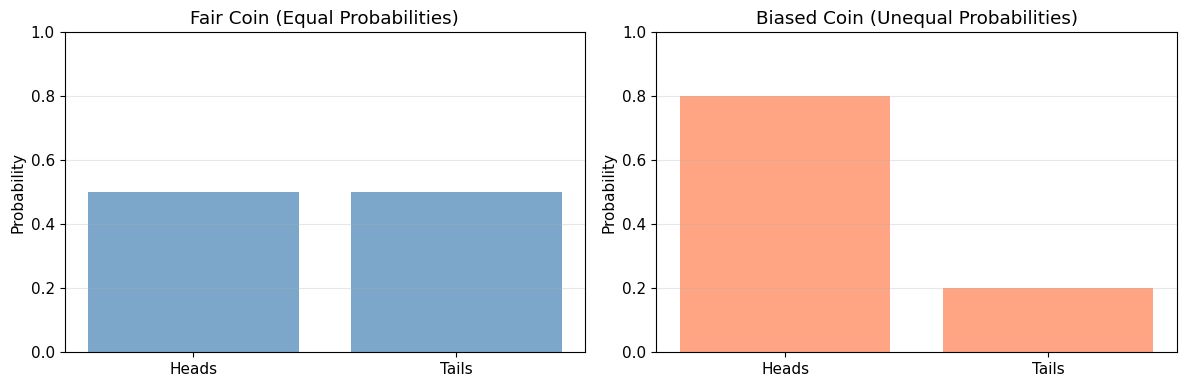

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Fair coin
axes[0].bar(['Heads', 'Tails'], fair_coin, color='steelblue', alpha=0.7)
axes[0].set_ylabel('Probability')
axes[0].set_title('Fair Coin (Equal Probabilities)')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Biased coin
axes[1].bar(['Heads', 'Tails'], biased_coin, color='coral', alpha=0.7)
axes[1].set_ylabel('Probability')
axes[1].set_title('Biased Coin (Unequal Probabilities)')
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Notice how the **fair coin has equal probabilities** (maximum uncertainty), while the **biased coin is skewed** toward heads (less uncertain).

## 3. Information Content: Measuring "Surprise"

### Why Logarithms? Why Bits?

**Information content** (also called "surprisal") measures how surprising an event is. The formula is:

$$I(p) = -\log_2(p)$$

**Why the logarithm?** Three key reasons:

1. **Inverse relationship**: We want high probability → low information, low probability → high information. The log naturally gives us this.

2. **Additive property**: When two **independent** events happen together, their information should add:
   - Flipping heads (0.5) AND rolling a 6 (1/6) has probability 0.5 × 1/6
   - Using logs: $\log(0.5 \times 1/6) = \log(0.5) + \log(1/6)$ ✓
   
3. **Natural units**: Logs give us a nice scale for measurement.

**Why bits specifically?** 

Using $\log_2$ (logarithm base 2) gives us **bits** - think of it as **"how many yes/no questions do I need to ask?"**

Example: Guessing one of 8 equally likely outcomes
- Probability of each: $p = 1/8$
- Information: $I(1/8) = -\log_2(1/8) = 3$ bits
- This means: **you need 3 yes/no questions** to identify which outcome occurred!
  - Q1: "Is it in the first half?" → narrows to 4
  - Q2: "Is it in the first half of those?" → narrows to 2  
  - Q3: "Is it the first one?" → identifies exactly which one!

A **fair coin flip** has exactly **1 bit** of information because you need exactly 1 yes/no question to determine the outcome!

**Units**: 
- Base 2 → **bits** (common in computer science)
- Base $e$ → **nats** (common in machine learning, mathematically cleaner)
- Base 10 → **hartleys** or **bans** (rarely used)

The choice is just convention - they're all measuring the same thing, just in different units (like meters vs feet).

**Information content** (also called "surprisal") measures how surprising an event is.

**Intuition**: Rare events are more surprising than common events.

The information content of an event with probability $p$ is:

$$I(p) = -\log_2(p)$$

**Why this formula?**
- **Rare events** (low $p$) → **high information** (high surprise)
- **Common events** (high $p$) → **low information** (low surprise)
- The logarithm makes information additive for independent events

Let's compute information content for different probabilities.

In [6]:
def information_content(p):
    """Compute information content (surprisal) in bits."""
    return -torch.log2(p)

# Different event probabilities
probs = torch.tensor([0.01, 0.1, 0.5, 0.9, 0.99])
info = information_content(probs)

for p, i in zip(probs, info):
    print(f"P = {p:.2f} → Information = {i:.2f} bits")

P = 0.01 → Information = 6.64 bits
P = 0.10 → Information = 3.32 bits
P = 0.50 → Information = 1.00 bits
P = 0.90 → Information = 0.15 bits
P = 0.99 → Information = 0.01 bits


**Key observation**: A very rare event ($p = 0.01$) contains ~6.6 bits of information, while a very common event ($p = 0.99$) contains only ~0.01 bits.

Let's visualize the relationship between probability and information.

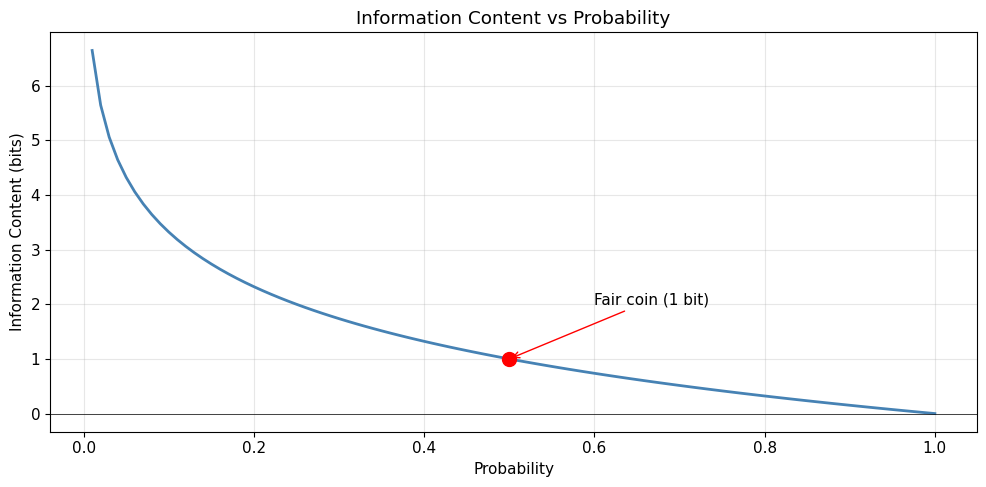

In [7]:
p_range = torch.linspace(0.01, 1.0, 100)
info_range = information_content(p_range)

plt.figure(figsize=(10, 5))
plt.plot(p_range, info_range, linewidth=2, color='steelblue')
plt.xlabel('Probability')
plt.ylabel('Information Content (bits)')
plt.title('Information Content vs Probability')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linewidth=0.5)

# Annotate key points
plt.scatter([0.5], [1.0], color='red', s=100, zorder=5)
plt.annotate('Fair coin (1 bit)', xy=(0.5, 1.0), xytext=(0.6, 2),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=11)

plt.tight_layout()
plt.show()

Notice the **inverse relationship**: as probability increases (event becomes more certain), information content decreases (event becomes less surprising).

A **fair coin flip** ($p = 0.5$) has exactly **1 bit** of information — this is the maximum information for a binary event!

### The Formula

**Entropy** is the **expected information content** across all possible outcomes of a distribution.

For a discrete distribution $P$ with outcomes $x_i$:

$$H(P) = -\sum_i P(x_i) \log_2 P(x_i)$$

**Properties**:
- **Uniform distributions** (all outcomes equally likely) → **maximum entropy** (most uncertain)
- **Peaked distributions** (one outcome very likely) → **low entropy** (more certain)
- **Deterministic** (one outcome is certain) → **zero entropy** (no uncertainty)

## 4. Entropy: Expected Information

**Entropy** is the **expected information content** across all possible outcomes of a distribution.

For a discrete distribution $P$ with outcomes $x_i$:

$$H(P) = -\sum_i P(x_i) \log_2 P(x_i)$$

**Intuition**: Entropy measures the **average surprise** or **uncertainty** in a distribution.
- **Uniform distributions** (all outcomes equally likely) → **maximum entropy** (most uncertain)
- **Peaked distributions** (one outcome very likely) → **low entropy** (more certain)

Let's implement entropy and compare our two coin distributions.

In [8]:
def entropy(p):
    """Compute entropy in bits."""
    # Avoid log(0) by filtering out zero probabilities
    p_nonzero = p[p > 0]
    return -(p_nonzero * torch.log2(p_nonzero)).sum()

# Compute entropy for both coins
H_fair = entropy(fair_coin)
H_biased = entropy(biased_coin)

print(f"Entropy of fair coin: {H_fair:.3f} bits")
print(f"Entropy of biased coin: {H_biased:.3f} bits")
print(f"\nDifference: {H_fair - H_biased:.3f} bits")

Entropy of fair coin: 1.000 bits
Entropy of biased coin: 0.722 bits

Difference: 0.278 bits


**Key insight**: The fair coin has **higher entropy** (1 bit) than the biased coin (~0.72 bits).

This makes sense! When we flip a fair coin, we're **more uncertain** about the outcome. The biased coin is more **predictable** (heads is more likely), so it has lower entropy.

Let's explore how entropy changes as we vary the bias of a coin.

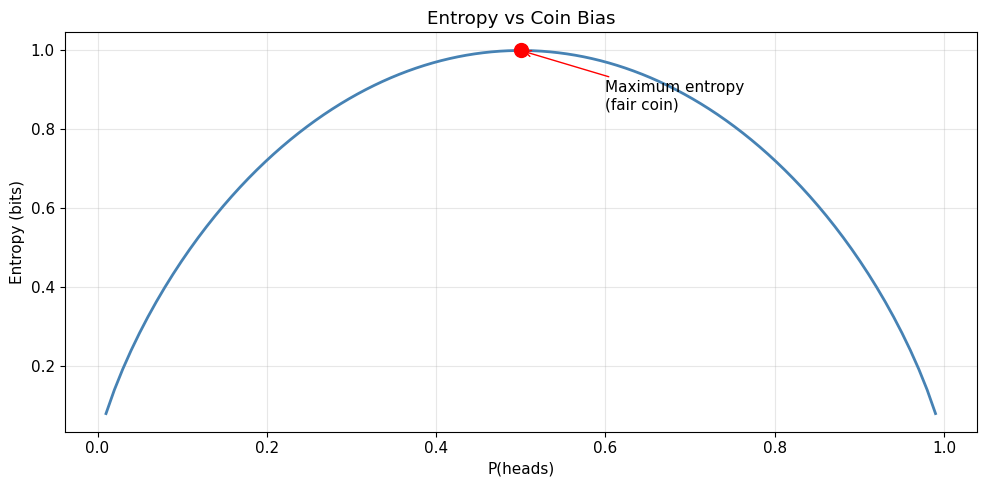

In [9]:
# Create coins with different biases
biases = torch.linspace(0.01, 0.99, 100)
entropies = torch.tensor([entropy(torch.tensor([b, 1-b])) for b in biases])

plt.figure(figsize=(10, 5))
plt.plot(biases, entropies, linewidth=2, color='steelblue')
plt.xlabel('P(heads)')
plt.ylabel('Entropy (bits)')
plt.title('Entropy vs Coin Bias')
plt.grid(True, alpha=0.3)

# Mark maximum entropy at p=0.5
plt.scatter([0.5], [1.0], color='red', s=100, zorder=5)
plt.annotate('Maximum entropy\n(fair coin)', xy=(0.5, 1.0), xytext=(0.6, 0.85),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=11)

plt.tight_layout()
plt.show()

### The Formula

**Cross-entropy** measures the expected information content when we use distribution $Q$ to encode events that actually come from distribution $P$.

$$H(P, Q) = -\sum_i P(x_i) \log_2 Q(x_i)$$

**Intuition breakdown**:
- $P(x_i)$ = how often event $x_i$ actually happens
- $\log_2 Q(x_i)$ = how many bits your code (designed for $Q$) uses for event $x_i$
- $H(P,Q)$ = average bits per event when reality is $P$ but you coded for $Q$

**Key properties**:
- $H(P, Q) \geq H(P)$ (always at least as large as entropy - using wrong code can't be better!)
- $H(P, P) = H(P)$ (when your code matches reality, you get optimal encoding)
- $H(P, Q) \neq H(Q, P)$ (cross-entropy is asymmetric - order matters!)

**Beautiful symmetry!** Entropy is **maximized when the distribution is uniform** ($p = 0.5$) and **minimized at the extremes** (when one outcome is nearly certain).

## 5. Cross-Entropy: Encoding with the Wrong Distribution

**Cross-entropy** measures the expected information content when we use distribution $Q$ to encode events that actually come from distribution $P$.

$$H(P, Q) = -\sum_i P(x_i) \log_2 Q(x_i)$$

**Intuition**: If $P$ is the **true distribution** and $Q$ is our **model/approximation**, cross-entropy tells us how many bits we need on average to encode samples from $P$ using a code optimized for $Q$.

**Key property**: $H(P, Q) \geq H(P)$ (cross-entropy is always at least as large as entropy)

Let's compute cross-entropy between our two coin distributions.

### The Formula

**KL divergence** (also called relative entropy) is the **extra bits needed** when using $Q$ instead of the optimal code for $P$.

$$D_{KL}(P \| Q) = H(P, Q) - H(P) = \sum_i P(x_i) \log_2 \frac{P(x_i)}{Q(x_i)}$$

**Two equivalent interpretations**: 

1. **Via cross-entropy**: Extra cost = (Cost with wrong code) - (Cost with perfect code)
   $$D_{KL}(P \| Q) = H(P, Q) - H(P)$$

2. **Via log ratio**: Expected log ratio of true vs approximate probabilities
   $$D_{KL}(P \| Q) = \mathbb{E}_{x \sim P}\left[\log \frac{P(x)}{Q(x)}\right]$$

**Properties**:
- $D_{KL}(P \| Q) \geq 0$ (always non-negative)
- $D_{KL}(P \| Q) = 0$ if and only if $P = Q$ everywhere
- $D_{KL}(P \| Q) \neq D_{KL}(Q \| P)$ (asymmetric - order matters!)

**Reading the notation**: "$D_{KL}(P \| Q)$" reads as:
- "KL divergence **from** $Q$ **to** $P$"
- "How much information is lost when using $Q$ to approximate $P$"  
- "The cost of using $Q$ when $P$ is the truth"

In [10]:
def cross_entropy(p, q):
    """Compute cross-entropy H(P, Q) in bits."""
    # Only sum over events that can happen in P (p > 0)
    mask = p > 0
    return -(p[mask] * torch.log2(q[mask])).sum()

# Cross-entropies between our distributions
H_fair_fair = cross_entropy(fair_coin, fair_coin)  # Should equal entropy
H_fair_biased = cross_entropy(fair_coin, biased_coin)  # Fair → biased
H_biased_fair = cross_entropy(biased_coin, fair_coin)  # Biased → fair

print("Cross-entropies:")
print(f"H(Fair, Fair) = {H_fair_fair:.3f} bits  [same as H(Fair) = {H_fair:.3f}]")
print(f"H(Fair, Biased) = {H_fair_biased:.3f} bits")
print(f"H(Biased, Fair) = {H_biased_fair:.3f} bits")

Cross-entropies:
H(Fair, Fair) = 1.000 bits  [same as H(Fair) = 1.000]
H(Fair, Biased) = 1.322 bits
H(Biased, Fair) = 1.000 bits


**Important observations**:
1. When $P = Q$, cross-entropy equals entropy: $H(P, P) = H(P)$
2. Cross-entropy is **asymmetric**: $H(P, Q) \neq H(Q, P)$
3. Using the "wrong" distribution increases the bits needed

## 6. KL Divergence: The "Extra" Information

**KL divergence** (also called relative entropy) measures the **extra bits needed** when using $Q$ instead of the optimal code for $P$.

$$D_{KL}(P \| Q) = H(P, Q) - H(P) = \sum_i P(x_i) \log_2 \frac{P(x_i)}{Q(x_i)}$$

**Intuition**: 
- $D_{KL}(P \| Q)$ = "How much **information is lost** when we use $Q$ to approximate $P$"
- $D_{KL}(P \| Q) = 0$ if and only if $P = Q$
- $D_{KL}(P \| Q) > 0$ otherwise

**Read as**: "KL divergence **from** $Q$ **to** $P$" or "divergence of $Q$ from $P$"

Let's implement KL divergence.

In [11]:
def kl_divergence(p, q):
    """Compute KL divergence D_KL(P || Q) in bits."""
    mask = p > 0
    return (p[mask] * torch.log2(p[mask] / q[mask])).sum()

# Alternative: Cross-entropy minus entropy
def kl_divergence_alt(p, q):
    return cross_entropy(p, q) - entropy(p)

# Compute KL divergences
KL_fair_biased = kl_divergence(fair_coin, biased_coin)
KL_biased_fair = kl_divergence(biased_coin, fair_coin)

# Verify alternative formula
KL_fair_biased_alt = kl_divergence_alt(fair_coin, biased_coin)

print("KL Divergences:")
print(f"D_KL(Fair || Biased) = {KL_fair_biased:.3f} bits")
print(f"D_KL(Biased || Fair) = {KL_biased_fair:.3f} bits")
print(f"\nVerify: {KL_fair_biased:.3f} = {KL_fair_biased_alt:.3f} ✓")

KL Divergences:
D_KL(Fair || Biased) = 0.322 bits
D_KL(Biased || Fair) = 0.278 bits

Verify: 0.322 = 0.322 ✓


**Critical insight**: KL divergence is **asymmetric**!

- $D_{KL}(\text{Fair} \| \text{Biased}) \neq D_{KL}(\text{Biased} \| \text{Fair})$

This asymmetry matters when choosing which direction to measure. The direction affects what we're optimizing for.

Let's visualize what KL divergence represents using our cross-entropy decomposition.

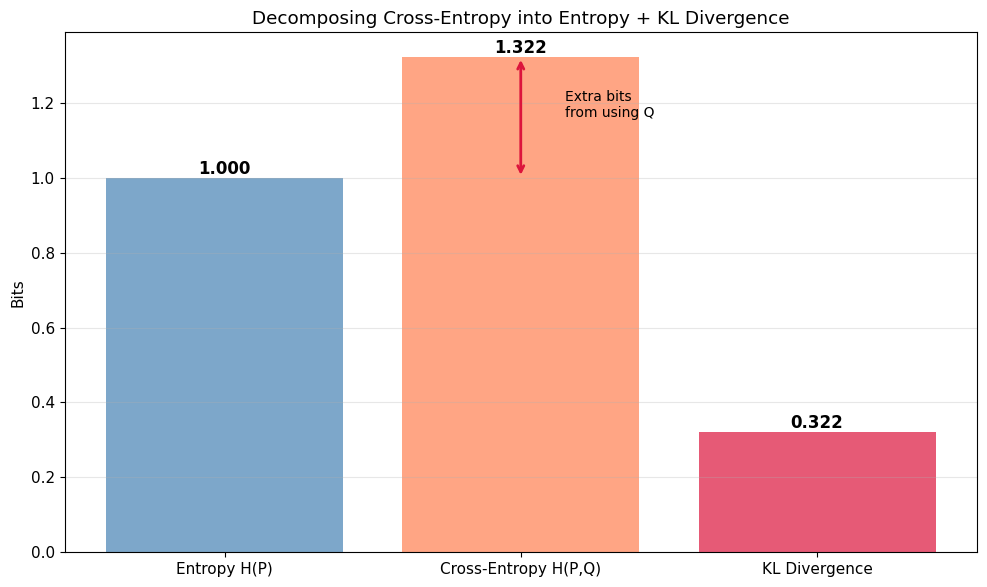

In [12]:
# Components of KL divergence
H_p = entropy(fair_coin)
H_pq = cross_entropy(fair_coin, biased_coin)
KL = H_pq - H_p

plt.figure(figsize=(10, 6))
bars = plt.bar(['Entropy H(P)', 'Cross-Entropy H(P,Q)', 'KL Divergence'], 
               [H_p, H_pq, KL],
               color=['steelblue', 'coral', 'crimson'],
               alpha=0.7)
plt.ylabel('Bits')
plt.title('Decomposing Cross-Entropy into Entropy + KL Divergence')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Show relationship
plt.annotate('', xy=(1, H_pq), xytext=(1, H_p),
            arrowprops=dict(arrowstyle='<->', color='crimson', linewidth=2))
plt.text(1.15, (H_pq + H_p)/2, 'Extra bits\nfrom using Q', fontsize=10)

plt.tight_layout()
plt.show()

**Interpretation**: When we encode samples from the fair coin using a code optimized for the biased coin, we need ~0.28 extra bits per sample on average.

## 7. Properties of KL Divergence

### 7.1 Non-Negativity

KL divergence is **always non-negative**: $D_{KL}(P \| Q) \geq 0$

It equals zero if and only if $P = Q$.

Let's verify this property.

In [13]:
# Test various distribution pairs
test_cases = [
    (torch.tensor([0.5, 0.5]), torch.tensor([0.5, 0.5]), "Same"),
    (torch.tensor([0.9, 0.1]), torch.tensor([0.1, 0.9]), "Opposite"),
    (torch.tensor([0.7, 0.3]), torch.tensor([0.65, 0.35]), "Close"),
    (torch.tensor([0.99, 0.01]), torch.tensor([0.01, 0.99]), "Extreme opposite"),
]

print("KL Divergence Non-Negativity Test:")
print("=" * 60)
for p, q, desc in test_cases:
    kl = kl_divergence(p, q)
    print(f"{desc:20s} D_KL(P||Q) = {kl:.4f} bits (>= 0 ✓)")

KL Divergence Non-Negativity Test:
Same                 D_KL(P||Q) = 0.0000 bits (>= 0 ✓)
Opposite             D_KL(P||Q) = 2.5359 bits (>= 0 ✓)
Close                D_KL(P||Q) = 0.0081 bits (>= 0 ✓)
Extreme opposite     D_KL(P||Q) = 6.4968 bits (>= 0 ✓)


All KL divergences are non-negative, with the identical distribution pair having exactly zero divergence.

### 7.2 Asymmetry

KL divergence is **not symmetric**: $D_{KL}(P \| Q) \neq D_{KL}(Q \| P)$

This means **order matters**! Let's explore what this asymmetry means.

In [14]:
# Compare both directions
distributions = [
    (torch.tensor([0.8, 0.2]), torch.tensor([0.5, 0.5])),
    (torch.tensor([0.9, 0.1]), torch.tensor([0.3, 0.7])),
    (torch.tensor([0.95, 0.05]), torch.tensor([0.05, 0.95])),
]

print("KL Divergence Asymmetry:")
print("=" * 70)
for i, (p, q) in enumerate(distributions, 1):
    kl_pq = kl_divergence(p, q)
    kl_qp = kl_divergence(q, p)
    ratio = kl_pq / kl_qp if kl_qp > 0 else float('inf')
    print(f"Case {i}: P={p.tolist()}, Q={q.tolist()}")
    print(f"  D_KL(P||Q) = {kl_pq:.4f} bits")
    print(f"  D_KL(Q||P) = {kl_qp:.4f} bits")
    print(f"  Ratio: {ratio:.2f}x different\n")

KL Divergence Asymmetry:
Case 1: P=[0.800000011920929, 0.20000000298023224], Q=[0.5, 0.5]
  D_KL(P||Q) = 0.2781 bits
  D_KL(Q||P) = 0.3219 bits
  Ratio: 0.86x different

Case 2: P=[0.8999999761581421, 0.10000000149011612], Q=[0.30000001192092896, 0.699999988079071]
  D_KL(P||Q) = 1.1457 bits
  D_KL(Q||P) = 1.4897 bits
  Ratio: 0.77x different

Case 3: P=[0.949999988079071, 0.05000000074505806], Q=[0.05000000074505806, 0.949999988079071]
  D_KL(P||Q) = 3.8231 bits
  D_KL(Q||P) = 3.8231 bits
  Ratio: 1.00x different



**Important**: The direction of KL divergence has different meanings:
- $D_{KL}(P \| Q)$: Information lost when using $Q$ to approximate $P$ (where $P$ is true distribution)
- $D_{KL}(Q \| P)$: Information gained when updating from prior $P$ to posterior $Q$

In machine learning:
- **Forward KL** $D_{KL}(P_{\text{data}} \| P_{\text{model}})$: Mode-seeking, avoids placing mass where data has none
- **Reverse KL** $D_{KL}(P_{\text{model}} \| P_{\text{data}})$: Mode-covering, spreads mass to cover all data modes

### 7.3 Not a Metric

Because of asymmetry and violation of the triangle inequality, KL divergence is **not a distance metric**.

However, we can make it symmetric by averaging both directions. This is called **Jenson-Shannon (JS) divergence**.

In [15]:
def js_divergence(p, q):
    """Compute symmetric Jensen-Shannon divergence."""
    # Average distribution
    m = (p + q) / 2
    # JS is average of two KL divergences
    return (kl_divergence(p, m) + kl_divergence(q, m)) / 2

# Compare KL and JS
p = torch.tensor([0.8, 0.2])
q = torch.tensor([0.3, 0.7])

kl_pq = kl_divergence(p, q)
kl_qp = kl_divergence(q, p)
js = js_divergence(p, q)
js_reverse = js_divergence(q, p)

print(f"P = {p.tolist()}, Q = {q.tolist()}")
print(f"\nKL Divergence (asymmetric):")
print(f"  D_KL(P||Q) = {kl_pq:.4f} bits")
print(f"  D_KL(Q||P) = {kl_qp:.4f} bits")
print(f"\nJS Divergence (symmetric):")
print(f"  D_JS(P,Q) = {js:.4f} bits")
print(f"  D_JS(Q,P) = {js_reverse:.4f} bits")
print(f"\nSymmetric: {abs(js - js_reverse) < 1e-6} ✓")

P = [0.800000011920929, 0.20000000298023224], Q = [0.30000001192092896, 0.699999988079071]

KL Divergence (asymmetric):
  D_KL(P||Q) = 0.7706 bits
  D_KL(Q||P) = 0.8406 bits

JS Divergence (symmetric):
  D_JS(P,Q) = 0.1912 bits
  D_JS(Q,P) = 0.1912 bits

Symmetric: True ✓


JS divergence is **symmetric** and bounded, making it useful when we need a true distance measure. It's used in GANs and other applications.

## 8. Continuous Distributions: Gaussian KL Divergence

So far we've looked at discrete distributions. In machine learning, we often work with **continuous distributions**, especially **Gaussians**.

For continuous distributions, we replace sums with integrals:

$$D_{KL}(P \| Q) = \int p(x) \log \frac{p(x)}{q(x)} dx$$

For two **univariate Gaussians** $P = \mathcal{N}(\mu_1, \sigma_1^2)$ and $Q = \mathcal{N}(\mu_2, \sigma_2^2)$, there's a **closed-form solution**:

$$D_{KL}(P \| Q) = \log \frac{\sigma_2}{\sigma_1} + \frac{\sigma_1^2 + (\mu_1 - \mu_2)^2}{2\sigma_2^2} - \frac{1}{2}$$

Let's implement Gaussian KL divergence.

In [16]:
def kl_gaussian(mu1, sigma1, mu2, sigma2):
    """KL divergence between two univariate Gaussians."""
    return (torch.log(sigma2 / sigma1) + 
            (sigma1**2 + (mu1 - mu2)**2) / (2 * sigma2**2) - 0.5)

# Two Gaussians
mu1, sigma1 = 0.0, 1.0  # Standard normal
mu2, sigma2 = 0.5, 1.5  # Shifted and wider

kl = kl_gaussian(torch.tensor(mu1), torch.tensor(sigma1), 
                 torch.tensor(mu2), torch.tensor(sigma2))

print(f"D_KL(N({mu1}, {sigma1}²) || N({mu2}, {sigma2}²)) = {kl:.4f} nats")

D_KL(N(0.0, 1.0²) || N(0.5, 1.5²)) = 0.1832 nats


Note: We're using **natural logarithms** here (nats instead of bits), which is standard in ML.

Let's visualize these Gaussians and their KL divergence.

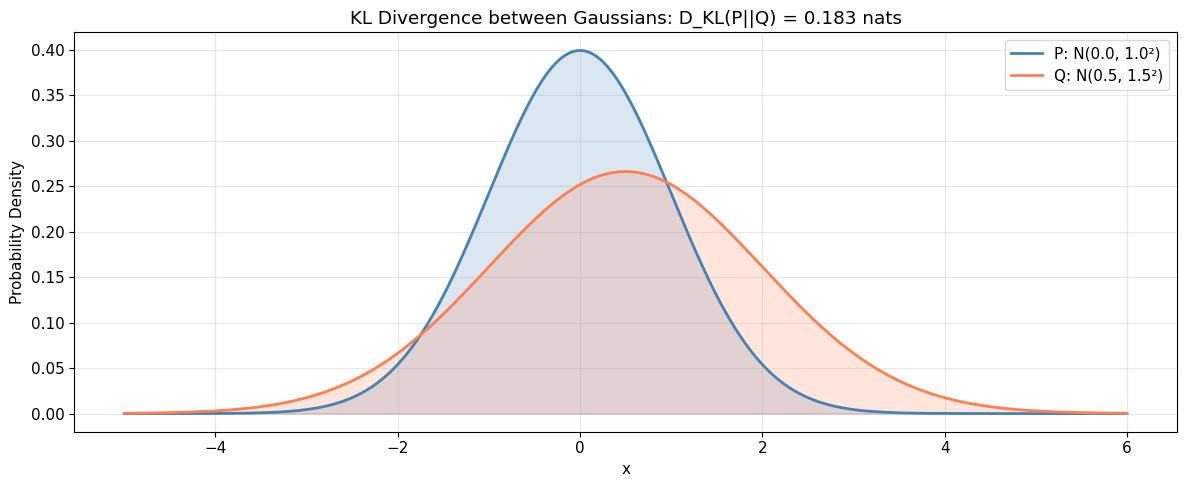

In [17]:
x = torch.linspace(-5, 6, 1000)

# Compute PDFs using scipy for visualization
p1 = stats.norm.pdf(x, mu1, sigma1)
p2 = stats.norm.pdf(x, mu2, sigma2)

plt.figure(figsize=(12, 5))
plt.plot(x, p1, label=f'P: N({mu1}, {sigma1}²)', linewidth=2, color='steelblue')
plt.plot(x, p2, label=f'Q: N({mu2}, {sigma2}²)', linewidth=2, color='coral')
plt.fill_between(x, 0, p1, alpha=0.2, color='steelblue')
plt.fill_between(x, 0, p2, alpha=0.2, color='coral')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.title(f'KL Divergence between Gaussians: D_KL(P||Q) = {kl:.3f} nats')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Special Case: KL from Standard Normal

In VAEs, we often compute $D_{KL}(\mathcal{N}(\mu, \sigma^2) \| \mathcal{N}(0, 1))$.

This simplifies to:
$$D_{KL} = -\frac{1}{2} \sum_j \left(1 + \log(\sigma_j^2) - \mu_j^2 - \sigma_j^2\right)$$

This is the **regularization term** in the VAE loss!

In [18]:
def kl_gaussian_standard_prior(mu, log_sigma):
    """KL divergence from N(mu, sigma²) to standard normal N(0,1).
    
    This is the VAE regularization term.
    log_sigma is used for numerical stability.
    """
    return -0.5 * torch.sum(1 + 2*log_sigma - mu**2 - torch.exp(2*log_sigma))

# Example: encoding from VAE
mu_encoded = torch.tensor([0.5, -0.3, 0.8])
log_sigma_encoded = torch.tensor([-0.5, -0.2, -0.8])

kl_vae = kl_gaussian_standard_prior(mu_encoded, log_sigma_encoded)
print(f"VAE KL term: {kl_vae:.4f} nats")
print(f"\nThis encourages the encoder to produce distributions close to N(0,1)")

VAE KL term: 1.1100 nats

This encourages the encoder to produce distributions close to N(0,1)


## 9. Visualizing KL Divergence Landscapes

Let's create a **heatmap** showing how KL divergence changes as we vary two Gaussian parameters.

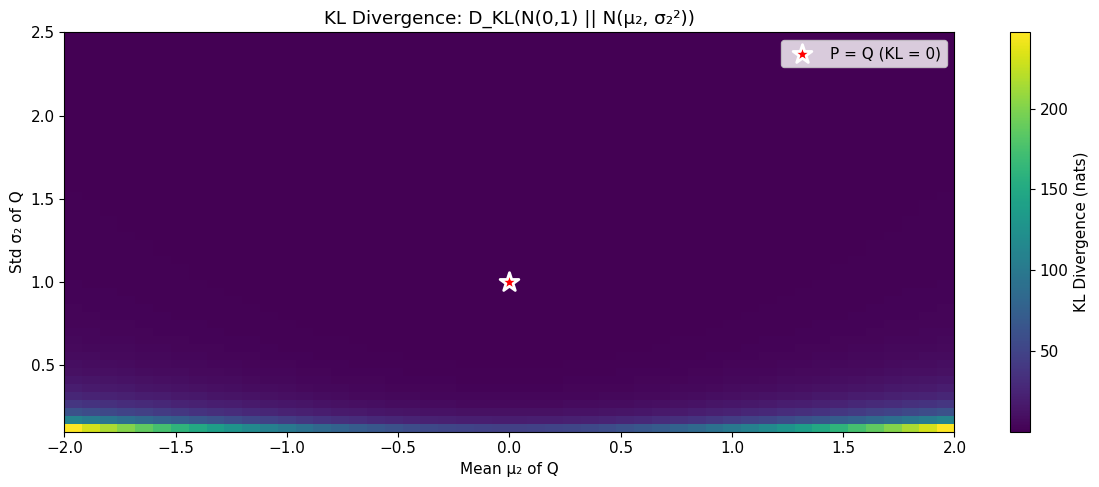

In [19]:
# Fix P as standard normal, vary Q's mean and std
mu1, sigma1 = 0.0, 1.0

mu_range = torch.linspace(-2, 2, 50)
sigma_range = torch.linspace(0.1, 2.5, 50)

# Compute KL for each combination
kl_grid = torch.zeros(len(sigma_range), len(mu_range))
for i, sigma2 in enumerate(sigma_range):
    for j, mu2 in enumerate(mu_range):
        kl_grid[i, j] = kl_gaussian(
            torch.tensor(mu1), torch.tensor(sigma1),
            mu2, sigma2
        )

plt.figure(figsize=(12, 5))
plt.imshow(kl_grid, extent=[mu_range[0], mu_range[-1], sigma_range[0], sigma_range[-1]],
          origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='KL Divergence (nats)')
plt.xlabel('Mean μ₂ of Q')
plt.ylabel('Std σ₂ of Q')
plt.title('KL Divergence: D_KL(N(0,1) || N(μ₂, σ₂²))')

# Mark the minimum (where P = Q)
plt.scatter([mu1], [sigma1], color='red', s=200, marker='*', 
           edgecolors='white', linewidths=2, zorder=5, label='P = Q (KL = 0)')
plt.legend()
plt.tight_layout()
plt.show()

**Key observation**: KL divergence is **minimized** (dark region) when $Q$'s parameters match $P$'s parameters, and grows as they diverge.

The star marks where $D_{KL} = 0$ (when $P = Q$).

## 10. KL Divergence in Machine Learning

### 10.1 Variational Autoencoders (VAEs)

The VAE loss function has two terms:

$$\mathcal{L} = \underbrace{\mathbb{E}_{z \sim q}[\log p(x|z)]}_{\text{Reconstruction}} + \underbrace{D_{KL}(q(z|x) \| p(z))}_{\text{Regularization}}$$

The KL term encourages the **encoder distribution** $q(z|x)$ to stay close to the **prior** $p(z)$ (usually $\mathcal{N}(0, I)$).

This prevents the latent space from becoming too irregular and helps with generation.

In [20]:
# Simulate VAE loss components
latent_dim = 10

# Encoder outputs (typical values during training)
mu = torch.randn(latent_dim) * 0.5
log_sigma = torch.randn(latent_dim) * 0.3 - 0.5  # Negative to keep sigma < 1

# KL term
kl_loss = kl_gaussian_standard_prior(mu, log_sigma)

# Typical reconstruction loss (negative log-likelihood)
reconstruction_loss = torch.tensor(50.0)  # Example value

# Total VAE loss
vae_loss = reconstruction_loss + kl_loss

print("VAE Loss Components:")
print(f"  Reconstruction: {reconstruction_loss:.2f}")
print(f"  KL Divergence: {kl_loss:.2f}")
print(f"  Total Loss: {vae_loss:.2f}")
print(f"\nKL term prevents latent code from becoming too far from N(0,I)")

VAE Loss Components:
  Reconstruction: 50.00
  KL Divergence: 2.83
  Total Loss: 52.83

KL term prevents latent code from becoming too far from N(0,I)


### 10.2 Policy Optimization in RL

In reinforcement learning, algorithms like **TRPO** and **PPO** use KL divergence to ensure policy updates aren't too large:

$$\max_{\theta} \mathbb{E}[\text{advantage}] \quad \text{s.t.} \quad D_{KL}(\pi_{\theta_{\text{old}}} \| \pi_{\theta}) \leq \delta$$

This **trust region** approach prevents catastrophic policy changes.

In [21]:
# Example: Action distributions before/after policy update
# Discrete action space (e.g., 4 actions)
old_policy = torch.softmax(torch.tensor([1.0, 2.0, 0.5, 1.5]), dim=0)
new_policy = torch.softmax(torch.tensor([1.1, 2.2, 0.4, 1.6]), dim=0)  # Small update

kl_policy = kl_divergence(old_policy, new_policy)

print("Policy Update:")
print(f"  Old policy: {old_policy.numpy()}")
print(f"  New policy: {new_policy.numpy()}")
print(f"  D_KL(old || new): {kl_policy:.6f} bits")
print(f"\nSmall KL → conservative update (safe) ✓")

Policy Update:
  Old policy: [0.1674051  0.45505422 0.10153633 0.27600434]
  New policy: [0.16261557 0.48852417 0.0807525  0.26810774]
  D_KL(old || new): 0.005525 bits

Small KL → conservative update (safe) ✓


### 10.3 Model Comparison and Selection

KL divergence can measure how well a model distribution matches the data distribution. Lower KL means better fit.

In [22]:
# Empirical distribution from data
data_counts = torch.tensor([50, 30, 15, 5])  # Observed counts
data_dist = data_counts / data_counts.sum()  # Normalize

# Three candidate models
model1 = torch.tensor([0.5, 0.3, 0.15, 0.05])  # Perfect match!
model2 = torch.tensor([0.4, 0.35, 0.15, 0.1])  # Slightly off
model3 = torch.tensor([0.25, 0.25, 0.25, 0.25])  # Uniform (poor fit)

models = [(model1, "Model 1"), (model2, "Model 2"), (model3, "Model 3 (uniform)")]

print("Model Selection via KL Divergence:")
print(f"Data distribution: {data_dist.numpy()}\n")

for model, name in models:
    kl = kl_divergence(data_dist, model)
    print(f"{name}: D_KL(data || model) = {kl:.4f} bits")

print("\nLower KL → better fit to data ✓")

Model Selection via KL Divergence:
Data distribution: [0.5  0.3  0.15 0.05]

Model 1: D_KL(data || model) = 0.0000 bits
Model 2: D_KL(data || model) = 0.0442 bits
Model 3 (uniform): D_KL(data || model) = 0.3523 bits

Lower KL → better fit to data ✓


## 11. Forward vs Reverse KL: A Critical Distinction

The **direction** of KL divergence matters significantly in optimization.

**Forward KL**: $D_{KL}(P_{\text{data}} \| Q_{\text{model}})$
- **Mode-seeking** behavior
- Model concentrates on data's high-probability regions
- Avoids putting mass where data has none
- Used in maximum likelihood estimation

**Reverse KL**: $D_{KL}(Q_{\text{model}} \| P_{\text{data}})$
- **Mode-covering** behavior  
- Model spreads out to cover all data modes
- Used in variational inference

Let's visualize this with a bimodal distribution.

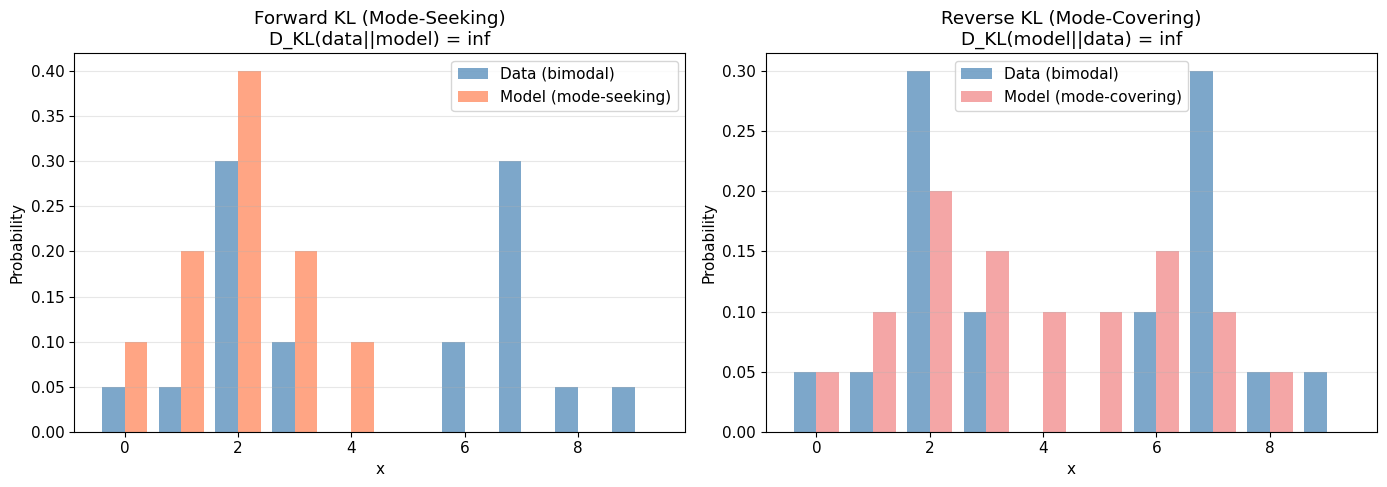

Forward KL encourages model to focus on one mode (mode-seeking)
Reverse KL encourages model to cover both modes (mode-covering)


In [23]:
# Create a bimodal "data" distribution (mixture of two peaks)
x = torch.linspace(0, 9, 10)
data_dist = torch.tensor([0.05, 0.05, 0.3, 0.1, 0.0, 0.0, 0.1, 0.3, 0.05, 0.05])
data_dist = data_dist / data_dist.sum()  # Normalize

# Two candidate models (unimodal - can only capture one mode well)
model_left = torch.tensor([0.1, 0.2, 0.4, 0.2, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0])
model_left = model_left / model_left.sum()

model_spread = torch.tensor([0.05, 0.1, 0.2, 0.15, 0.1, 0.1, 0.15, 0.1, 0.05, 0.0])
model_spread = model_spread / model_spread.sum()

# Compute both directions
forward_left = kl_divergence(data_dist, model_left)
reverse_left = kl_divergence(model_left, data_dist)

forward_spread = kl_divergence(data_dist, model_spread)
reverse_spread = kl_divergence(model_spread, data_dist)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mode-seeking (forward KL optimal)
axes[0].bar(x - 0.2, data_dist, width=0.4, label='Data (bimodal)', alpha=0.7, color='steelblue')
axes[0].bar(x + 0.2, model_left, width=0.4, label='Model (mode-seeking)', alpha=0.7, color='coral')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Probability')
axes[0].set_title(f'Forward KL (Mode-Seeking)\nD_KL(data||model) = {forward_left:.3f}')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Mode-covering (reverse KL optimal)
axes[1].bar(x - 0.2, data_dist, width=0.4, label='Data (bimodal)', alpha=0.7, color='steelblue')
axes[1].bar(x + 0.2, model_spread, width=0.4, label='Model (mode-covering)', alpha=0.7, color='lightcoral')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Probability')
axes[1].set_title(f'Reverse KL (Mode-Covering)\nD_KL(model||data) = {reverse_spread:.3f}')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Forward KL encourages model to focus on one mode (mode-seeking)")
print("Reverse KL encourages model to cover both modes (mode-covering)")

**Key insight**: 
- **Forward KL** heavily penalizes placing probability where data has none → focuses on one mode
- **Reverse KL** heavily penalizes missing probability where data has mass → spreads to cover modes

This is why **variational inference** (which uses reverse KL) tends to produce overly broad approximations!

## 12. Interactive Exploration

Let's create an interactive tool to explore how KL divergence changes with distribution parameters.

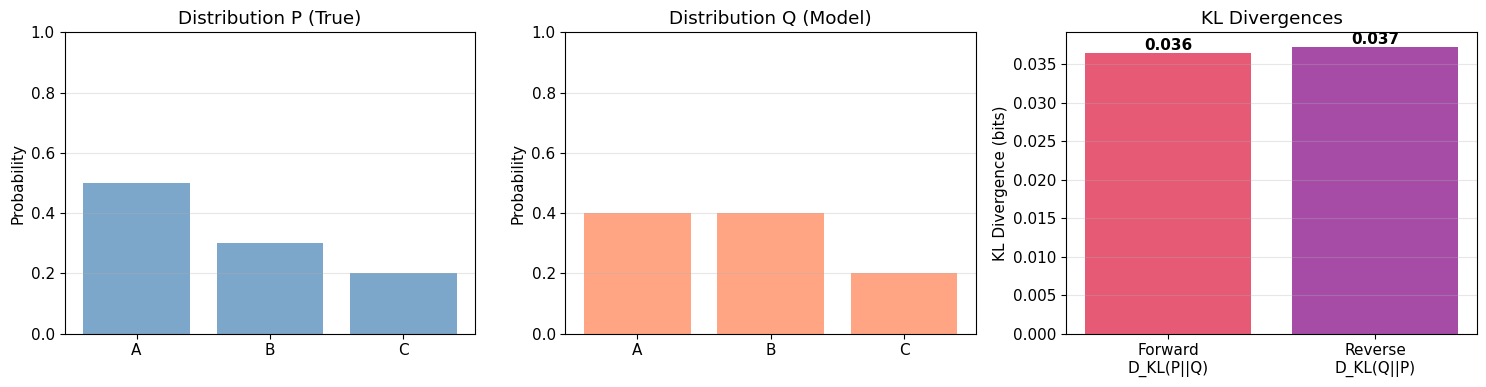

In [24]:
def plot_kl_exploration(p_vals, q_vals):
    """
    Visualize KL divergence for a 3-outcome distribution.
    p_vals and q_vals are probabilities for first two outcomes;
    third is computed to sum to 1.
    """
    # Complete distributions
    p = torch.tensor([p_vals[0], p_vals[1], 1 - p_vals[0] - p_vals[1]])
    q = torch.tensor([q_vals[0], q_vals[1], 1 - q_vals[0] - q_vals[1]])
    
    # Compute divergences
    kl_pq = kl_divergence(p, q)
    kl_qp = kl_divergence(q, p)
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Distribution P
    axes[0].bar(['A', 'B', 'C'], p, color='steelblue', alpha=0.7)
    axes[0].set_ylim([0, 1])
    axes[0].set_ylabel('Probability')
    axes[0].set_title('Distribution P (True)')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Distribution Q
    axes[1].bar(['A', 'B', 'C'], q, color='coral', alpha=0.7)
    axes[1].set_ylim([0, 1])
    axes[1].set_ylabel('Probability')
    axes[1].set_title('Distribution Q (Model)')
    axes[1].grid(axis='y', alpha=0.3)
    
    # KL divergences
    axes[2].bar(['Forward\nD_KL(P||Q)', 'Reverse\nD_KL(Q||P)'], 
               [kl_pq, kl_qp],
               color=['crimson', 'purple'],
               alpha=0.7)
    axes[2].set_ylabel('KL Divergence (bits)')
    axes[2].set_title('KL Divergences')
    axes[2].grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, (label, val) in enumerate(zip(['Forward', 'Reverse'], [kl_pq, kl_qp])):
        axes[2].text(i, val, f'{val:.3f}', 
                    ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Example: Try different values!
plot_kl_exploration(
    p_vals=[0.5, 0.3],  # P: [0.5, 0.3, 0.2]
    q_vals=[0.4, 0.4]   # Q: [0.4, 0.4, 0.2]
)

**Try it yourself!** Modify the values above and re-run to see how KL divergence changes.

Experiments to try:
- Make P and Q identical → both KL values should be zero
- Make them very different → KL values should be large
- Swap P and Q values → notice the asymmetry!

## 13. Common Pitfalls and Numerical Stability

When implementing KL divergence, watch out for these common issues:

1. **Division by zero**: If $Q(x) = 0$ but $P(x) > 0$, KL divergence is infinite
2. **Logarithm of zero**: Need to handle $\log(0)$ carefully
3. **Numerical precision**: Small probabilities can cause issues

Let's see these problems and solutions.

In [25]:
# Problem: Q has zero where P has mass
p = torch.tensor([0.5, 0.5, 0.0])
q_bad = torch.tensor([0.5, 0.0, 0.5])  # Zero where p is non-zero!

try:
    kl_bad = kl_divergence(p, q_bad)
    print(f"KL divergence: {kl_bad}")
    if torch.isinf(kl_bad):
        print("Result: INFINITE (Q=0 where P>0)")
except:
    print("Error: Cannot compute (division by zero)")

KL divergence: inf
Result: INFINITE (Q=0 where P>0)


**Solution**: Add a small epsilon for numerical stability, or use PyTorch's built-in function.

In [26]:
def kl_divergence_stable(p, q, eps=1e-10):
    """Numerically stable KL divergence."""
    # Clip to avoid log(0)
    p_safe = torch.clamp(p, min=eps)
    q_safe = torch.clamp(q, min=eps)
    
    mask = p > eps
    return (p_safe[mask] * torch.log(p_safe[mask] / q_safe[mask])).sum()

# Or use PyTorch's built-in (recommended!)
import torch.nn.functional as F

# PyTorch expects log-probabilities for numerical stability
p_log = torch.log(p + 1e-10)
q_log = torch.log(q_bad + 1e-10)

kl_pytorch = F.kl_div(q_log, p, reduction='sum', log_target=False)

print(f"KL (stable): {kl_divergence_stable(p, q_bad):.3f}")
print(f"KL (PyTorch): {kl_pytorch:.3f}")
print("\nUsing PyTorch's F.kl_div is recommended for production code!")

KL (stable): 11.166
KL (PyTorch): 11.166

Using PyTorch's F.kl_div is recommended for production code!


**Best practice**: Use `torch.nn.functional.kl_div()` for numerical stability and automatic differentiation in real applications.

## 14. Key Takeaways

Let's summarize what we've learned about KL divergence:

### Core Concepts

1. **Information content** measures "surprise": $I(p) = -\log p$

2. **Entropy** is expected information: $H(P) = -\sum P(x) \log P(x)$
   - Measures uncertainty in a distribution
   - Maximum for uniform distributions

3. **Cross-entropy** uses wrong distribution: $H(P, Q) = -\sum P(x) \log Q(x)$
   - Measures bits needed when using $Q$ to encode $P$

4. **KL divergence** is the extra cost: $D_{KL}(P \| Q) = H(P, Q) - H(P)$
   - Measures information lost when approximating $P$ with $Q$
   - Always non-negative: $D_{KL} \geq 0$
   - Zero if and only if $P = Q$

### Key Properties

- **Asymmetric**: $D_{KL}(P \| Q) \neq D_{KL}(Q \| P)$
- **Not a metric**: Doesn't satisfy triangle inequality
- **Direction matters**:
  - Forward KL: mode-seeking
  - Reverse KL: mode-covering

### Applications in ML

- **VAEs**: Regularization term to keep latent distributions close to prior
- **RL**: Trust regions for safe policy updates (TRPO, PPO)
- **Model selection**: Measure goodness-of-fit
- **Variational inference**: Approximate intractable posteriors

### Practical Tips

- Use `torch.nn.functional.kl_div()` for numerical stability
- Add epsilon to avoid log(0)
- For Gaussians, use closed-form solutions
- Remember: order matters! Choose direction based on application

**Most importantly**: KL divergence is a fundamental tool for measuring how distributions differ, with applications throughout machine learning and information theory!